Overview of Gradient Descent
- What "gradient descent" means and why we need it
- The gradient descent algorithm

<font color="lime">Gradient Descent is the single most important algorithmn in deep learning!</font>


<font color="teal">Gradient Descent: Theory and motivation</font>

How deep learning models learn:

<font color="#00FFFF	
">1)</font> Guess a solution

<font color="#00FFFF	
">2)</font> Compute the error (mistakes)


<font color="#00FFFF">
3)</font> Learn from mistakes and modify the parameters

![alt text](DUDL-Pytorch/img/gd-1.png)

It's common to use 'W' but you can just as easily call it 'x'  Gradient means the exact same thing as derivative. The concept is the same. In one dimension and two dimensions it's possible to visualize the process of gradient descent. In higher dimensions, it's impossible we just have to trust the algebra and the math. The math is the same regardless of the number of dimensions. 

Lets practice by taking the derivative of this polynomial function:

$f(x) = 3x^{2} - 3x + 4$

becomes:

$f(x) = 6x^{1} - 3x^{0} + 4$

becomes:

$f(x) = 6x - 3 + 4$

becomes:

$f(x) = 6x -3 $  <font color="green"># because 4 has no variable, it disappears</font>


Now lets treat our function, f(x), as if it were an error function. This is the function we want to minimize. Now remember we don't want to minimize the derivative. We want to minimize the function and the function is minimized where the derivative is zero. 

So the question becomes how do we use gradient descent.

<font color="orange">Initialize random guess of minimum</font>

<font color="yellow">loop over training iterations</font>

<font color="aqua">&emsp;&emsp;&emsp;compute derivative at guess min</font>

<font color="lightgreen">&emsp;&emsp;&emsp;Updated guess min is itself minus derivative scaled by learning rate</font>


To prove a correct/incorrect answer, we can compute the real minimum of the fcn analytically.
E.g. the following derivative from above

<font color="teal">

$\frac{df}{dx} = 6x -3$

Set to 0</font>

$0 = 6x -3$

$3=6x$

$x = \frac{3}{6}$

$x = 0.5$

This is not the same as what gradient descent gave us which was: 0.4951546... but it was darn close but it's NOT the solution as we just proven 0.5 is the solution. GD is not guaranteed to give us the optimal best soltuion.  There are several circumstances  that can make gradient descent algo eithe rgo completely wrong or just something like the 0.495...where we're pretty close. 

One is using a poor choice of model parameters and two is we can stuck in a local minimum or a third issue is vanishing gradients or exploding gradients. 

Many of the problems have been overcome in the last decade or two. So there are some tricks that we use in DL that will get around some of the problems of GD. 

What about local minima?
![alt text](DUDL-Pytorch/img/gd-2.png)

The success of DL, in spite of the "problems" with GD, remains a mystery.

It's possible that ther are many good solutions (many equally good local minima). <font color="yellow">This interpretation is consitent with the huge diversity of weight configurations that produce similar model performance</font>

<font color="teal">Another possibility is that there are extremely few local minima in high-dimensional space.</font><font color="yellow"> This interpreation is consitent with the complexity and absurd dimensionality of DL models</font>

Note modern DL systems can have billions of dimensions!

<font color="orange">G.D. will get trapped in a local minimum only if that point is a minimimum in all directions! In other words multiple axis.</font>

Consider the case of 400,000 parameters i.e a 400,000 dimensional space. Although we don't know for sure, it is unlikely that EVERY single direction, all 400,000 directions have a minimum all at the exact same point. 

In an extremely high-D space, there might be very few local minima. We don't really know, as we've mentioned before, rather or not we're getting stuck in a local minima. It's hard to know for sure. So what to do about it? Well if things are performing well (accuracy that is), do nothing. 

Otherwise: <font color="lime">One possible solution:</font> Re-train the model many times (maybe 20 times or so) using different random weights (different starting locations on the loss landscape) and pick the model that does best. 

Another possible solution: <font color="yellow">Increase the dimensionality (complexity) of the model to have fewer local minima.</font>



<font color="teal" size="10px">Gradient Descent in 1D</font>

- How GD is implmented in code
- Learn how two important parameters (learning rate & training epochs) are implemented.
- Appreciate why gradient descent is not guranteed to give the correct answer.

The function and it's derivative

$f(x) = 3x^{2}  - 3x + 4$

Our goal in GD is to find the minimum of the above function. We can compute it's derivative:

$\frac{df}{dx} = 6x - 3$

Now we've determined previously (by solving for x) that the soltuion or right answer is 0.5



C:\Users\mpere\AppData\Local\Temp\ipykernel_448\3159755834.py:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


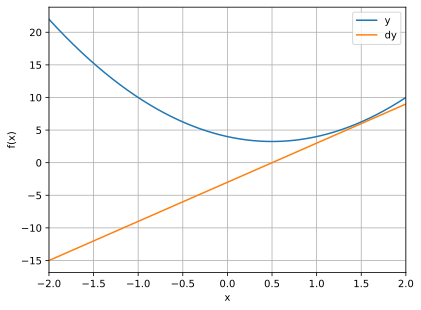

In [52]:
import numpy as np
import matplotlib.pyplot as plt 

# for changing some of the figure format. Draws in vector format instead of pixel format
from IPython import display
display.set_matplotlib_formats('svg')  


# These fcns are doing the math manually as u can see

def fx(x):
    return 3*x**2 -3*x+4

def deriv(x):
    return 6*x -3

# Plot the fcn and it's derivative

# From -2 to plus 2 in 2001 steps
x = np.linspace(-2,2,2001) 

# Plotting
plt.plot(x,fx(x),x,deriv(x))
plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['y','dy'])
plt.show()

In [53]:
# random starting point. just some random guess.From the vector x, 
# randomly choose one value. Recall the vector x = (-2,2)
localmin = np.random.choice(x,1)
print(localmin)
# learning parameters
learning_rate = 0.1
training_epochs = 100

# run through training. Loop over 100 training epochs
for i in range(training_epochs):
    # compute the gradient as the derivative of the function at our local minimum point

    grad = deriv(localmin)
    localmin = localmin - learning_rate*grad

print(localmin)



[1.63]
[0.5]


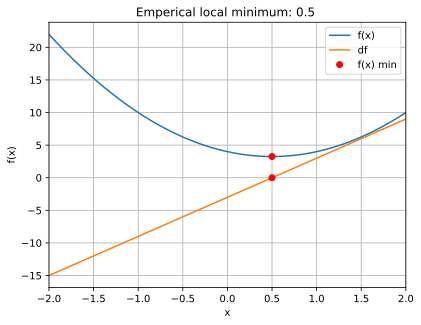

In [99]:
# plot the results
plt.plot(x,fx(x),x,deriv(x))
plt.plot(localmin,deriv(localmin),'ro')
plt.plot(localmin,fx(localmin),'ro')

plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['f(x)','df','f(x) min'])
plt.title('Emperical local minimum: %s '%localmin[0])
plt.show()


<font color="teal">Store th model parameters andoutputs on ea. iteration</font>

In [107]:
# random starting point
localmin = np.random.choice(x,1)
# learning parameters
learning_rate = 0.1
training_epochs = 100

# run through training and store the results
modelparams =  np.zeros((training_epochs,2))
for i in range(training_epochs):
    # compute the gradient as the derivative of the function at our local minimum point
    grad = deriv(localmin)
    localmin = localmin - learning_rate*grad
    # creating vector/matrix
    # modelparams[i,:] = localmin,grad # at ea. row store the guess and grdient
   # modelparams[i,:] = localmin,grad
    modelparams[i][0] = localmin[0]
    modelparams[i][1] = grad[0]

#print(modelparams)

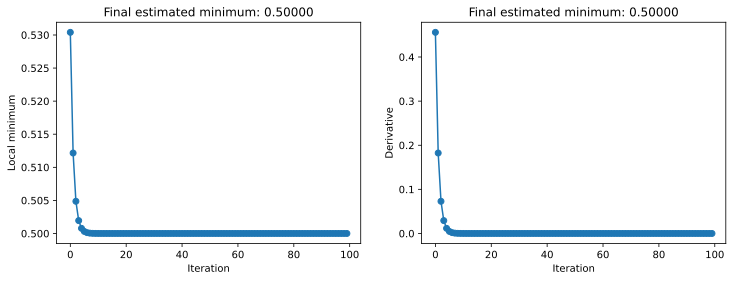

In [108]:
# plot the gradient over iterations

fig,ax = plt.subplots(1,2,figsize=(12,4))

for i in range(2):
    #ax[i].plot(modelparams[:,i],'o-')
    #ax[i].plot(modelparams[i,0],'o-')
    ax[i].plot(modelparams[:,i],'o-')
    ax[i].set_xlabel('Iteration')
    ax[i].set_title(f'Final estimated minimum: {localmin[0]:.5f}')

# two plots/subplots
ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')

plt.show()


In [ ]:
# the values on the top left chart, you can see they asymptotically  approach the true value